In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import joblib

In [2]:
try:
    profile_df = feature_df.copy()
    print("Using feature-engineered data from notebook memory")

except NameError:
    profile_df = pd.read_excel(
        "clinical_feature_engineered_data.xlsx",
        sheet_name="Feature_Engineered_Data"
    )
    print("Using saved feature-engineered data")

print("Dataset shape:", profile_df.shape)
profile_df.head()

Using saved feature-engineered data
Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [3]:
profile_df.columns = (
    profile_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(profile_df.columns.tolist())

['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [4]:
required_columns = [
    "patient_id",
    "age_years",
    "sex",
    "condition",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm",
    "recorded_allergy",
    "family_history",
    "adherence_level"
]

missing_columns = [
    column for column in required_columns
    if column not in profile_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required patient-profile columns are available.")

All required patient-profile columns are available.


In [5]:
if "pulse_pressure_mmhg" not in profile_df.columns:
    profile_df["pulse_pressure_mmhg"] = (
        profile_df["systolic_bp_mmhg"] -
        profile_df["diastolic_bp_mmhg"]
    )

if "allergy_recorded_flag" not in profile_df.columns:
    profile_df["allergy_recorded_flag"] = np.where(
        profile_df["recorded_allergy"]
        .str.strip()
        .str.lower()
        .eq("none recorded"),
        0,
        1
    )

if "family_history_flag" not in profile_df.columns:
    profile_df["family_history_flag"] = (
        profile_df["family_history"]
        .map({"No": 0, "Yes": 1})
    )

if "adherence_score" not in profile_df.columns:
    profile_df["adherence_score"] = (
        profile_df["adherence_level"]
        .map({
            "Low": 0,
            "Medium": 1,
            "High": 2
        })
    )

print("Derived profile features prepared.")

Derived profile features prepared.


In [6]:
patient_ids = profile_df["patient_id"].copy()

numeric_profile_features = [
    "age_years",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm",
    "pulse_pressure_mmhg",
    "allergy_recorded_flag",
    "family_history_flag",
    "adherence_score"
]

categorical_profile_features = [
    "sex",
    "condition",
    "recorded_allergy"
]

profile_features = (
    numeric_profile_features +
    categorical_profile_features
)

patient_profiles = profile_df[
    profile_features
].copy()

print("Patient profile shape:", patient_profiles.shape)
patient_profiles.head()

Patient profile shape: (500, 13)


,age_years,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,pulse_pressure_mmhg,allergy_recorded_flag,family_history_flag,adherence_score,sex,condition,recorded_allergy
0,28,97,132,85,214,73,47,0,0,2,Female,Seasonal Allergy,None recorded
1,80,80,123,79,189,59,44,0,1,1,Female,Acid Reflux,None recorded
2,36,86,121,66,192,82,55,0,0,1,Female,Asthma,None recorded
3,21,103,120,69,278,85,51,0,1,2,Male,High Cholesterol,None recorded
4,58,79,111,76,244,64,35,0,1,2,Male,High Cholesterol,None recorded


In [7]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [8]:
try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            encoder
        )
    ]
)

In [9]:
profile_transformer = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_profile_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_profile_features
        )
    ],
    remainder="drop"
)

print("Patient-profile transformer created.")

Patient-profile transformer created.


In [10]:
patient_profile_vectors = (
    profile_transformer.fit_transform(
        patient_profiles
    )
)

print(
    "Patient profile vector shape:",
    patient_profile_vectors.shape
)

Patient profile vector shape: (500, 23)


In [11]:
vector_feature_names = (
    profile_transformer.get_feature_names_out()
)

vector_feature_names = [
    name.replace("numeric__", "")
        .replace("categorical__", "")
        .replace("imputer__", "")
        .replace("scaler__", "")
        .replace("encoder__", "")
    for name in vector_feature_names
]

print("Number of vector features:", len(vector_feature_names))
print(vector_feature_names)

Number of vector features: 23
['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'pulse_pressure_mmhg', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'sex_Female', 'sex_Male', 'condition_Acid Reflux', 'condition_Asthma', 'condition_High Cholesterol', 'condition_Hypertension', 'condition_Seasonal Allergy', 'condition_Type 2 Diabetes', 'recorded_allergy_Latex', 'recorded_allergy_NSAID', 'recorded_allergy_None recorded', 'recorded_allergy_Penicillin', 'recorded_allergy_Sulfonamide']


In [12]:
patient_profile_vector_df = pd.DataFrame(
    patient_profile_vectors,
    columns=vector_feature_names
)

patient_profile_vector_df.insert(
    0,
    "patient_id",
    patient_ids.reset_index(drop=True)
)

print(
    "Profile-vector dataset shape:",
    patient_profile_vector_df.shape
)

patient_profile_vector_df.head()

Profile-vector dataset shape: (500, 24)


,patient_id,age_years,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,pulse_pressure_mmhg,allergy_recorded_flag,family_history_flag,...,condition_Asthma,condition_High Cholesterol,condition_Hypertension,condition_Seasonal Allergy,condition_Type 2 Diabetes,recorded_allergy_Latex,recorded_allergy_NSAID,recorded_allergy_None recorded,recorded_allergy_Penicillin,recorded_allergy_Sulfonamide
0,SYN-0001,-1.105540,-0.324550,0.254611,0.339678,0.424486,-0.316168,0.060504,-0.524891,-0.937923,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,SYN-0002,1.836230,-0.810147,-0.237972,-0.210259,-0.216422,-1.547763,-0.131368,-0.524891,1.066186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,SYN-0003,-0.652960,-0.638760,-0.347435,-1.401789,-0.139513,0.475572,0.572162,-0.524891,-0.937923,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,SYN-0004,-1.501547,-0.153163,-0.402166,-1.126821,2.065208,0.739485,0.316333,-0.524891,1.066186,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,SYN-0005,0.591635,-0.838712,-0.894749,-0.485228,1.193574,-1.107908,-0.706983,-0.524891,1.066186,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [13]:
profile_quality = pd.DataFrame({
    "check": [
        "Total patients",
        "Unique patient IDs",
        "Vector dimensions",
        "Missing vector values",
        "Infinite vector values"
    ],
    "result": [
        len(patient_profile_vector_df),
        patient_profile_vector_df[
            "patient_id"
        ].nunique(),
        patient_profile_vectors.shape[1],
        np.isnan(patient_profile_vectors).sum(),
        np.isinf(patient_profile_vectors).sum()
    ]
})

profile_quality

,check,result
0,Total patients,500
1,Unique patient IDs,500
2,Vector dimensions,23
3,Missing vector values,0
4,Infinite vector values,0


In [14]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

reduced_profile_vectors = pca.fit_transform(
    patient_profile_vectors
)

print(
    "Original dimensions:",
    patient_profile_vectors.shape[1]
)

print(
    "Reduced dimensions:",
    reduced_profile_vectors.shape[1]
)

print(
    "Explained variation:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Original dimensions: 23
Reduced dimensions: 11
Explained variation: 96.1 %


In [15]:
pca_column_names = [
    f"profile_component_{number}"
    for number in range(
        1,
        reduced_profile_vectors.shape[1] + 1
    )
]

reduced_profile_df = pd.DataFrame(
    reduced_profile_vectors,
    columns=pca_column_names
)

reduced_profile_df.insert(
    0,
    "patient_id",
    patient_ids.reset_index(drop=True)
)

reduced_profile_df.head()

,patient_id,profile_component_1,profile_component_2,profile_component_3,profile_component_4,profile_component_5,profile_component_6,profile_component_7,profile_component_8,profile_component_9,profile_component_10,profile_component_11
0,SYN-0001,0.420387,-0.883308,-0.064281,0.249386,-0.308309,1.604322,-0.725117,-0.546919,-0.220178,0.642761,0.710978
1,SYN-0002,-0.254218,-0.455843,-0.289766,1.472500,1.316486,-0.320656,1.617044,1.147254,-0.300530,0.591966,-0.351342
2,SYN-0003,-0.332390,-1.059143,-0.118233,-1.406107,-0.347446,0.623033,-0.162036,0.516504,-0.946359,0.598162,-0.612324
3,SYN-0004,-0.689087,-0.438710,-1.308339,-1.323200,-0.782238,1.887785,0.834399,-0.586466,1.691929,-0.711899,0.043111
4,SYN-0005,-1.231700,-0.489866,-1.228647,1.081820,0.774176,1.186673,1.183842,0.145589,0.742076,-0.831177,0.026677


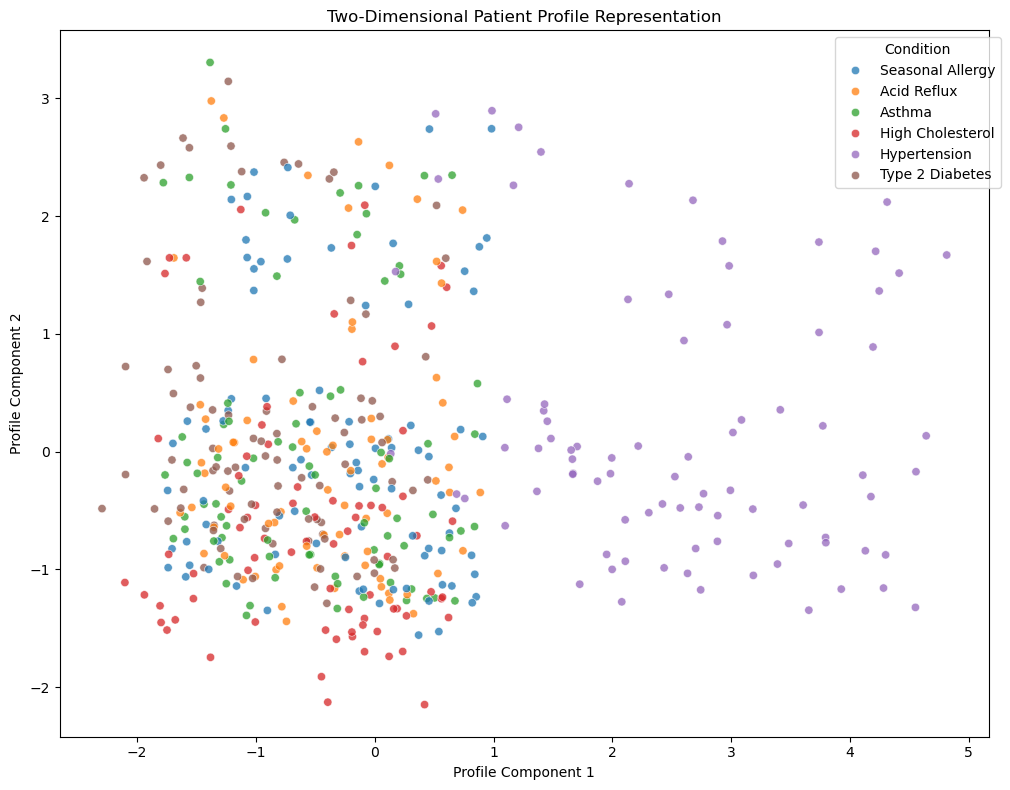

In [16]:
pca_visualization = PCA(
    n_components=2,
    random_state=42
)

profile_2d = pca_visualization.fit_transform(
    patient_profile_vectors
)

profile_visualization_df = pd.DataFrame({
    "component_1": profile_2d[:, 0],
    "component_2": profile_2d[:, 1],
    "condition": profile_df["condition"].values
})

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=profile_visualization_df,
    x="component_1",
    y="component_2",
    hue="condition",
    palette="tab10",
    alpha=0.75
)

plt.title("Two-Dimensional Patient Profile Representation")
plt.xlabel("Profile Component 1")
plt.ylabel("Profile Component 2")
plt.legend(title="Condition", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [17]:
profile_similarity_matrix = cosine_similarity(
    patient_profile_vectors
)

print(
    "Similarity matrix shape:",
    profile_similarity_matrix.shape
)

Similarity matrix shape: (500, 500)


In [18]:
def find_similar_patients(patient_id, top_n=5):

    matching_indices = patient_profile_vector_df.index[
        patient_profile_vector_df["patient_id"] == patient_id
    ].tolist()

    if not matching_indices:
        raise ValueError(
            f"Patient ID '{patient_id}' was not found."
        )

    patient_index = matching_indices[0]

    similarity_scores = (
        profile_similarity_matrix[patient_index]
    )

    similar_indices = np.argsort(
        similarity_scores
    )[::-1]

    # Remove the same patient
    similar_indices = [
        index for index in similar_indices
        if index != patient_index
    ][:top_n]

    results = profile_df.iloc[
        similar_indices
    ][
        [
            "patient_id",
            "age_years",
            "sex",
            "condition",
            "recorded_allergy"
        ]
    ].copy()

    results["profile_similarity"] = [
        similarity_scores[index]
        for index in similar_indices
    ]

    return results.reset_index(drop=True)

In [19]:
find_similar_patients(
    patient_id="SYN-0001",
    top_n=5
)

,patient_id,age_years,sex,condition,recorded_allergy,profile_similarity
0,SYN-0070,27,Female,Seasonal Allergy,None recorded,0.805260
1,SYN-0104,23,Female,Acid Reflux,None recorded,0.789036
2,SYN-0497,31,Male,Seasonal Allergy,None recorded,0.773130
3,SYN-0010,37,Female,Acid Reflux,None recorded,0.739943
4,SYN-0114,37,Female,High Cholesterol,None recorded,0.734689


In [20]:
output_file = "patient_profile_representation.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    patient_profile_vector_df.to_excel(
        writer,
        sheet_name="Full_Profile_Vectors",
        index=False
    )

    reduced_profile_df.to_excel(
        writer,
        sheet_name="Reduced_Profile_Vectors",
        index=False
    )

    profile_df[
        ["patient_id"] + profile_features
    ].to_excel(
        writer,
        sheet_name="Profile_Source_Data",
        index=False
    )

    profile_quality.to_excel(
        writer,
        sheet_name="Profile_Quality",
        index=False
    )

print("Patient profiles saved as:")
print(output_file)

Patient profiles saved as:
patient_profile_representation.xlsx


In [21]:
joblib.dump(
    profile_transformer,
    "patient_profile_transformer.pkl"
)

joblib.dump(
    pca,
    "patient_profile_pca.pkl"
)

print("Profile transformer and PCA model saved.")

Profile transformer and PCA model saved.
